In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('NHB_2017_Exp1.csv')
df.head()

,r1,r2,t,sub,rs,condition
0,0.987968,0.012032,1,1,-0.975936,reward
1,0.012032,0.005348,2,1,-0.006684,control
2,0.005348,0.994652,3,1,0.989305,transition
3,0.008690,0.987968,4,1,0.979278,reward
4,0.012032,0.994652,5,1,0.982620,reward


In [10]:
df.loc[(df['sub']==1)&(df['condition']=='transition')]['rs'].mean()

np.float64(0.863135026737968)

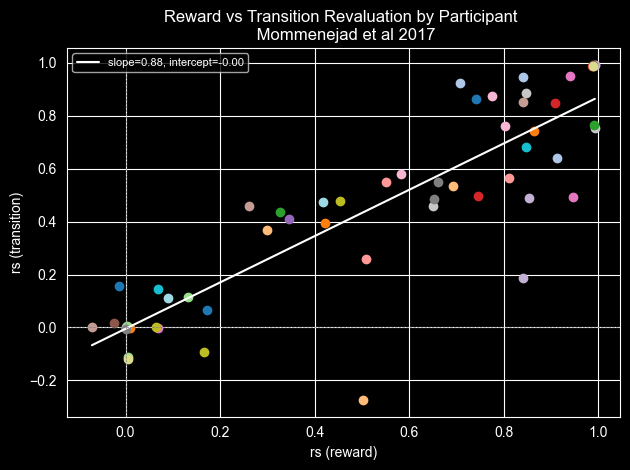

<Figure size 640x480 with 0 Axes>

In [18]:
from scipy import stats

sub_means = df.groupby(['sub', 'condition'])['rs'].mean().reset_index()

reward_df = sub_means[sub_means['condition'] == 'reward'].set_index('sub')['rs']
transition_df = sub_means[sub_means['condition'] == 'transition'].set_index('sub')['rs']

plot_df = pd.DataFrame({'reward': reward_df, 'transition': transition_df}).reset_index()

palette = sns.color_palette('tab20', n_colors=plot_df['sub'].nunique())
color_map = {sub: palette[i] for i, sub in enumerate(sorted(plot_df['sub'].unique()))}

slope, intercept, r, p, se = stats.linregress(plot_df['reward'], plot_df['transition'])

x = np.linspace(plot_df['reward'].min(), plot_df['reward'].max(), 100)
y = slope * x + intercept

fig, ax = plt.subplots()
for _, row in plot_df.iterrows():
    ax.scatter(row['reward'], row['transition'], color=color_map[row['sub']])

ax.plot(x, y, color='white', linewidth=1.5, label=f'slope={slope:.2f}, intercept={intercept:.2f}')
ax.legend(loc='upper left', fontsize=8)
ax.set_xlabel('rs (reward)')
ax.set_ylabel('rs (transition)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Reward vs Transition Revaluation by Participant \n Mommenejad et al 2017')
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

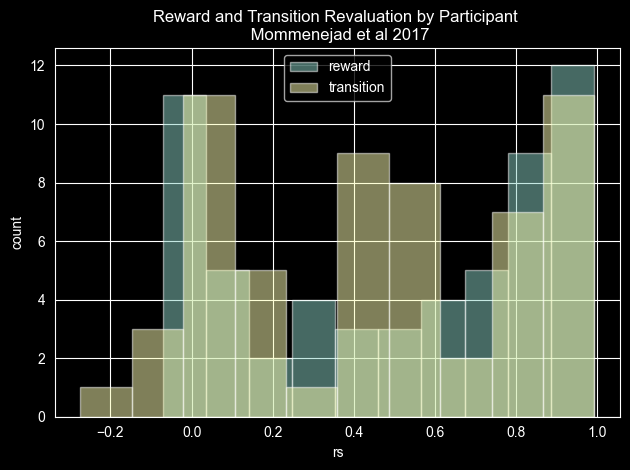

In [25]:
fig, ax = plt.subplots()
ax.hist(sub_means[sub_means['condition'] == 'reward']['rs'], alpha=0.5, label='reward')
ax.hist(sub_means[sub_means['condition'] == 'transition']['rs'], alpha=0.5, label='transition')
ax.set_xlabel('rs')
ax.set_ylabel('count')
ax.legend()
ax.set_title('Reward and Transition Revaluation by Participant \n Mommenejad et al 2017')
plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/q5/p9bc2kz92vgg9scqwhh46dsh0000gn/T/ipykernel_27986/984473847.py:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_title(f'Reward vs Transition Revaluation Difference by Participant \n mean={mean_diff:.3f} $\pm$ std={std_diff:.3f} \n Mommenejad et al 2017')


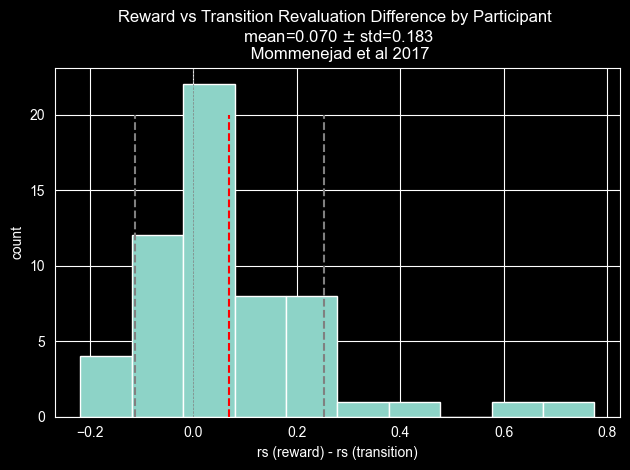

In [33]:
plot_df['diff'] = plot_df['reward'] - plot_df['transition']

mean_diff = plot_df['diff'].mean()
std_diff = plot_df['diff'].std()

fig, ax = plt.subplots()
ax.hist(plot_df['diff'])
ax.vlines(x=mean_diff, ymin=0,ymax=20, color='red', linewidth=1.5, linestyle='--')
ax.vlines(x=mean_diff+std_diff, ymin=0,ymax=20, color='gray', linewidth=1.5, linestyle='--')
ax.vlines(x=mean_diff-std_diff, ymin=0,ymax=20, color='gray', linewidth=1.5, linestyle='--')
ax.set_xlabel('rs (reward) - rs (transition)')
ax.set_ylabel('count')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Reward vs Transition Revaluation Difference by Participant \n mean={mean_diff:.3f} $\pm$ std={std_diff:.3f} \n Mommenejad et al 2017')
plt.tight_layout()
plt.show()

,sub,reward,transition,diff
0,1,0.741143,0.863135,-0.121992
1,2,0.912015,0.639205,0.272811
2,3,0.010445,-0.001671,0.012116
3,4,0.501337,-0.274064,0.775401
4,5,0.326705,0.437416,-0.110712
5,6,0.006267,-0.109876,0.116143
6,7,0.907838,0.849348,0.058489
7,8,0.811330,0.564840,0.246491
8,9,0.992647,0.992229,0.000418
9,10,0.854362,0.490057,0.364305


<bound method Series.max of 0        1
1        1
2        1
3        1
4        1
        ..
1155    58
1156    58
1157    58
1158    58
1159    58
Name: sub, Length: 1160, dtype: int64>

In [34]:
t_stat, p_val = stats.ttest_rel(plot_df['reward'], plot_df['transition'])
print(f't={t_stat:.3f}, p={p_val:.3f}')

t=2.893, p=0.005


In [35]:
t_stat, p_val = stats.ttest_1samp(plot_df['diff'], popmean=0)
print(f't={t_stat:.3f}, p={p_val:.3f}')

t=2.893, p=0.005


In [37]:
z_scores = np.abs(stats.zscore(plot_df['diff']))
outliers_z = plot_df[z_scores > 3]
print(f'{len(outliers_z)} outlier(s) detected (|z| > 3):')
print(outliers_z[['sub', 'reward', 'transition', 'diff']])

Q1, Q3 = plot_df['diff'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers_iqr = plot_df[(plot_df['diff'] < Q1 - 1.5*IQR) | (plot_df['diff'] > Q3 + 1.5*IQR)]
print(f'\n{len(outliers_iqr)} outlier(s) detected (IQR method):')
print(outliers_iqr[['sub', 'reward', 'transition', 'diff']])

2 outlier(s) detected (|z| > 3):
    sub    reward  transition      diff
3     4  0.501337   -0.274064  0.775401
29   30  0.840575    0.186748  0.653827

3 outlier(s) detected (IQR method):
    sub    reward  transition      diff
3     4  0.501337   -0.274064  0.775401
29   30  0.840575    0.186748  0.653827
52   53  0.945856    0.494652  0.451203


In [47]:
diff_filtered = plot_df[~plot_df['sub'].isin([4, 30,52])]['diff']
t_stat, p_val = stats.ttest_1samp(diff_filtered, popmean=0)
print(f't={t_stat:.3f}, p={p_val:.3f} (n={len(diff_filtered)})')

t=2.617, p=0.011 (n=55)


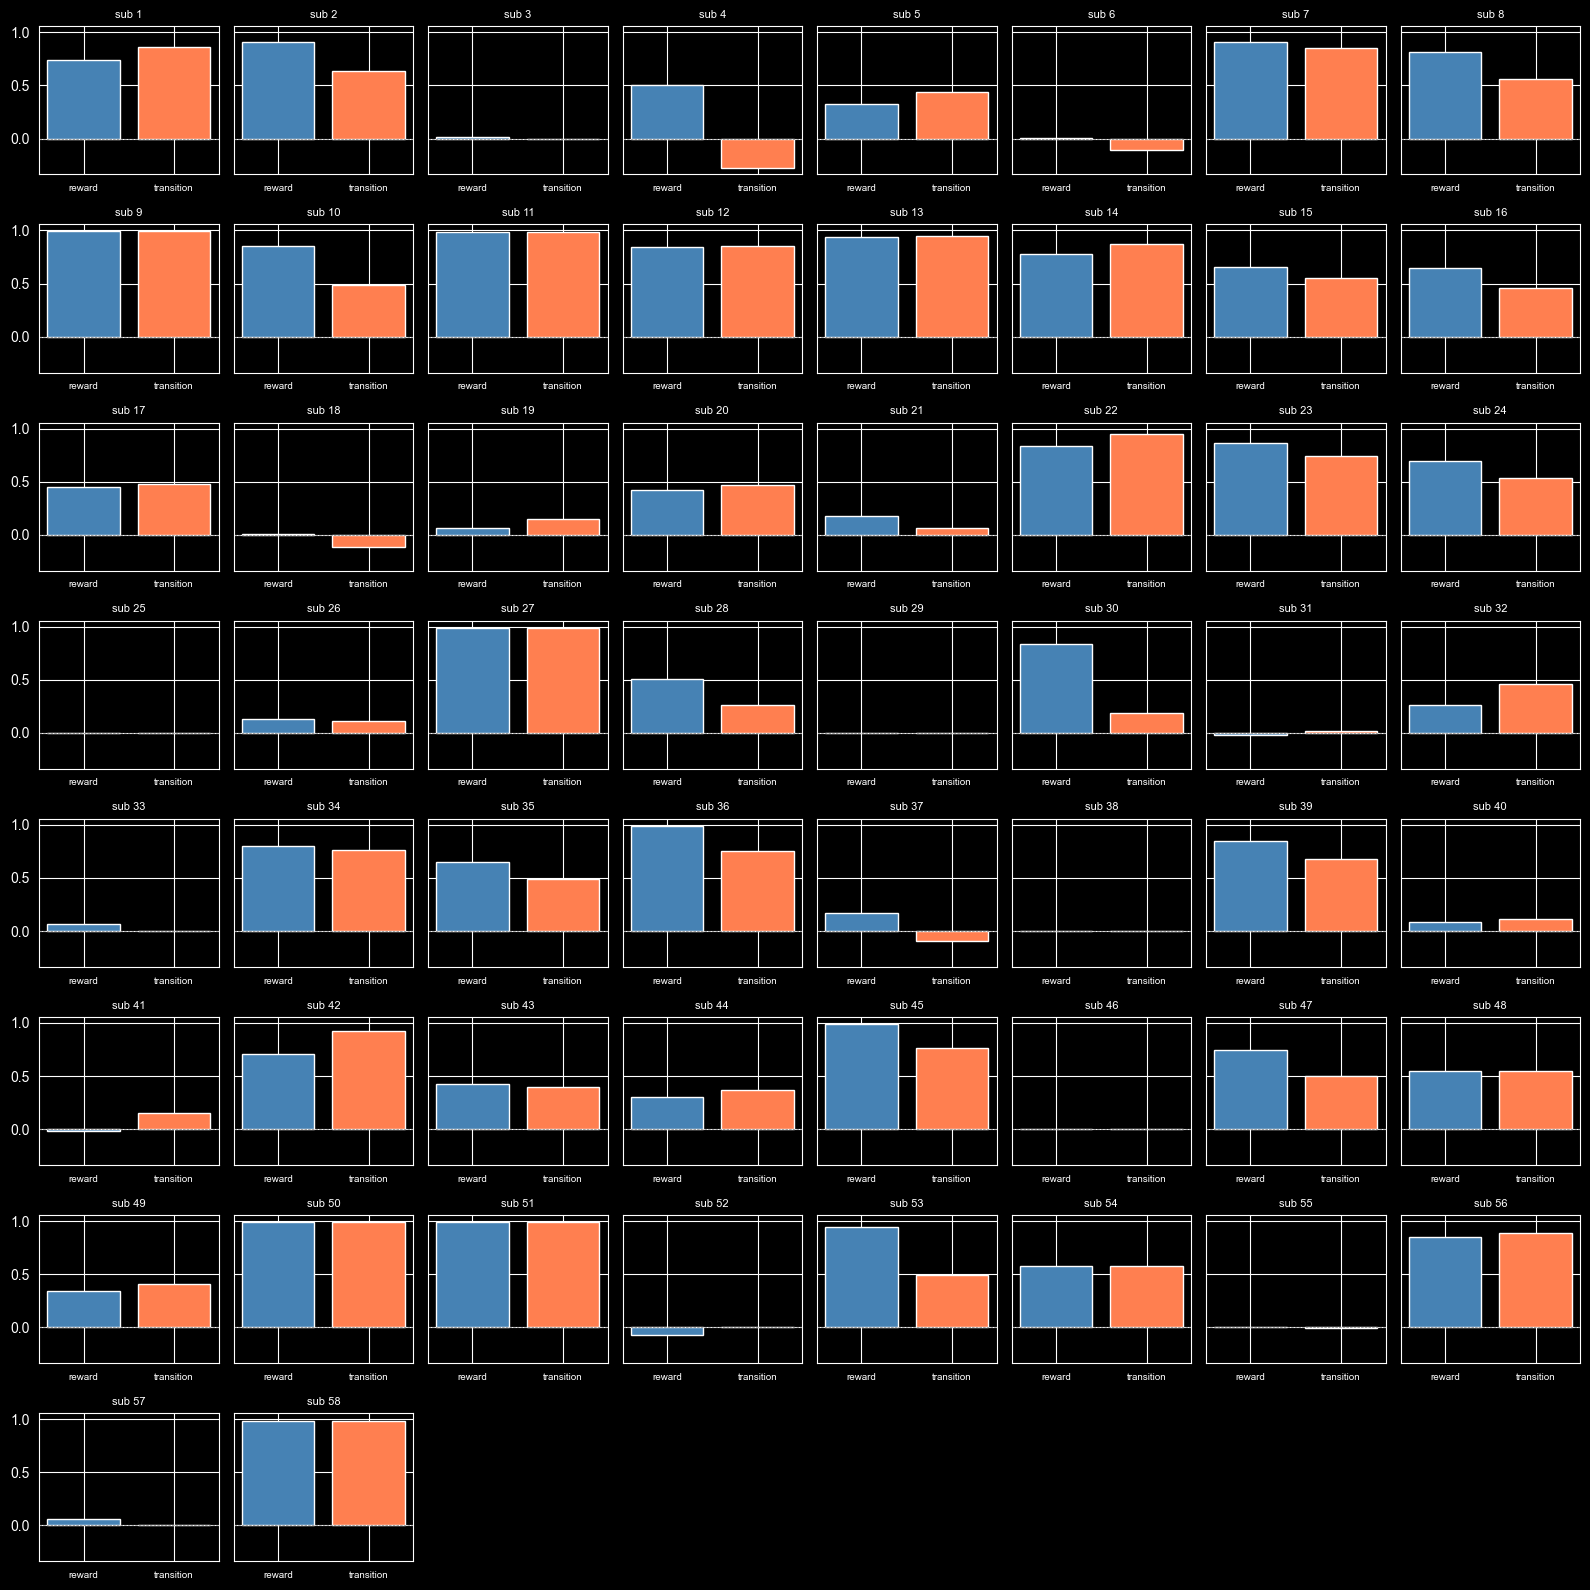

In [48]:
n_subs = len(plot_df)
n_cols = 8
n_rows = int(np.ceil(n_subs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2), sharey=True)
axes = axes.flatten()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax = axes[i]
    ax.bar(['reward', 'transition'], [row['reward'], row['transition']], color=['steelblue', 'coral'])
    ax.set_title(f'sub {int(row["sub"])}', fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.tick_params(axis='x', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [51]:
plot_df.to_csv('NHB_2017_Exp1_means.csv', index=False)